# 🚔 India District-Level IPC Crime Dashboard (2001–2014)

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import panel as pn
import param
import hvplot.pandas

pn.extension('tabulator', sizing_mode='stretch_width')
matplotlib.rcParams['figure.dpi'] = 100
plt.style.use('dark_background')
matplotlib.rcParams['axes.facecolor']  = '#1a1a2e'
matplotlib.rcParams['figure.facecolor'] = '#1a1a2e'
matplotlib.rcParams['text.color']       = '#e0e0e0'
matplotlib.rcParams['axes.labelcolor']  = '#e0e0e0'
matplotlib.rcParams['xtick.color']      = '#e0e0e0'
matplotlib.rcParams['ytick.color']      = '#e0e0e0'
matplotlib.rcParams['axes.edgecolor']   = '#444466'
matplotlib.rcParams['grid.color']       = '#333355'
print('Libraries loaded OK')


Libraries loaded OK


## 1 · Load & Clean Data

In [2]:
COMMON_COLS = [
    'STATE', 'DISTRICT', 'YEAR',
    'MURDER', 'RAPE', 'KIDNAPPING & ABDUCTION',
    'DACOITY', 'ROBBERY', 'BURGLARY', 'THEFT',
    'RIOTS', 'CRIMINAL BREACH OF TRUST', 'CHEATING',
    'ARSON', 'HURT/GREVIOUS HURT', 'DOWRY DEATHS',
    'CRUELTY BY HUSBAND OR HIS RELATIVES',
    'CAUSING DEATH BY NEGLIGENCE',
    'OTHER IPC CRIMES', 'TOTAL IPC CRIMES'
]
NUMERIC_COLS = [c for c in COMMON_COLS if c not in ('STATE','DISTRICT','YEAR')]

def safe_select(df, cols):
    for c in cols:
        if c not in df.columns:
            df[c] = 0
    return df[cols].copy()

d1 = pd.read_csv('dstrIPC_1.csv')
d1.columns = d1.columns.str.strip().str.upper()
d1.rename(columns={'STATE/UT': 'STATE'}, inplace=True)
d1['STATE']    = d1['STATE'].str.strip().str.title()
d1['DISTRICT'] = d1['DISTRICT'].str.strip().str.title()

d3 = pd.read_csv('dstrIPC_2013.csv')
d3.columns = d3.columns.str.strip().str.upper()
d3.rename(columns={'STATE/UT': 'STATE'}, inplace=True)
d3['STATE']    = d3['STATE'].str.strip().str.title()
d3['DISTRICT'] = d3['DISTRICT'].str.strip().str.title()

d4 = pd.read_csv('dstrIPC_1_2014.csv')
d4.rename(columns={
    'States/UTs': 'STATE', 'District': 'DISTRICT', 'Year': 'YEAR',
    'Murder': 'MURDER', 'Rape': 'RAPE',
    'Kidnapping & Abduction': 'KIDNAPPING & ABDUCTION',
    'Dacoity': 'DACOITY', 'Robbery': 'ROBBERY',
    'Burglary': 'BURGLARY', 'Theft': 'THEFT', 'Riots': 'RIOTS',
    'Criminal Breach of Trust': 'CRIMINAL BREACH OF TRUST',
    'Cheating': 'CHEATING', 'Arson': 'ARSON',
    'Hurt/Grievious Hurt': 'HURT/GREVIOUS HURT',
    'Dowry Deaths': 'DOWRY DEATHS',
    'Cruelty by Husband or his Relatives': 'CRUELTY BY HUSBAND OR HIS RELATIVES',
    'Causing Death by Negligence': 'CAUSING DEATH BY NEGLIGENCE',
    'Other IPC crimes': 'OTHER IPC CRIMES',
    'Total Cognizable IPC crimes': 'TOTAL IPC CRIMES',
}, inplace=True)
d4['STATE']    = d4['STATE'].str.strip().str.title()
d4['DISTRICT'] = d4['DISTRICT'].str.strip().str.title()

df = pd.concat(
    [safe_select(d1, COMMON_COLS),
     safe_select(d3, COMMON_COLS),
     safe_select(d4, COMMON_COLS)],
    ignore_index=True
)
df.fillna(0, inplace=True)
df[NUMERIC_COLS] = df[NUMERIC_COLS].astype(int)
df['YEAR'] = df['YEAR'].astype(int)

ALL_STATES = sorted(df['STATE'].unique().tolist())
ALL_YEARS  = sorted(df['YEAR'].unique().tolist())



In [3]:
print(f'Combined dataset: {df.shape[0]:,} rows | {df["STATE"].nunique()} states | {ALL_YEARS[0]}–{ALL_YEARS[-1]}')
df.head(3)

Combined dataset: 10,678 rows | 38 states | 2001–2014


,STATE,DISTRICT,YEAR,MURDER,RAPE,KIDNAPPING & ABDUCTION,DACOITY,ROBBERY,BURGLARY,THEFT,RIOTS,CRIMINAL BREACH OF TRUST,CHEATING,ARSON,HURT/GREVIOUS HURT,DOWRY DEATHS,CRUELTY BY HUSBAND OR HIS RELATIVES,CAUSING DEATH BY NEGLIGENCE,OTHER IPC CRIMES,TOTAL IPC CRIMES
0,Andhra Pradesh,Adilabad,2001,101,50,46,9,41,198,199,78,16,104,30,1131,16,175,181,1518,4154
1,Andhra Pradesh,Anantapur,2001,151,23,53,8,16,191,366,168,11,65,69,1543,7,154,270,754,4125
2,Andhra Pradesh,Chittoor,2001,101,27,59,4,14,237,723,156,33,209,38,2088,14,186,404,1262,5818


## 2 · EDA – Quick Summary

In [4]:
print('Missing values total:', df.isnull().sum().sum())
print()
print('Top 5 states by total IPC crimes (all years):')
print(df.groupby('STATE')['TOTAL IPC CRIMES'].sum()
        .sort_values(ascending=False).head()
        .apply(lambda x: f'{x:,}'))
print()
print('Year-wise national totals:')
print(df.groupby('YEAR')['TOTAL IPC CRIMES'].sum().apply(lambda x: f'{x:,}'))

Missing values total: 0

Top 5 states by total IPC crimes (all years):
STATE
Madhya Pradesh    5,827,292
Maharashtra       5,515,310
Tamil Nadu        4,913,910
Andhra Pradesh    4,703,200
Uttar Pradesh     4,649,988
Name: TOTAL IPC CRIMES, dtype: str

Year-wise national totals:
YEAR
2001    3,538,616
2002    3,560,660
2003    3,432,240
2004    3,664,020
2005    3,645,204
2006    3,756,586
2007    3,979,346
2008    4,186,758
2009    4,242,690
2010    4,449,662
2011    4,651,150
2012    4,774,376
2013    5,295,444
2014    5,717,878
Name: TOTAL IPC CRIMES, dtype: str


In [5]:
df[NUMERIC_COLS].describe().apply(lambda col: col.map(lambda x: f'{int(x):,}' if pd.notnull(x) else x))

,MURDER,RAPE,KIDNAPPING & ABDUCTION,DACOITY,ROBBERY,BURGLARY,THEFT,RIOTS,CRIMINAL BREACH OF TRUST,CHEATING,ARSON,HURT/GREVIOUS HURT,DOWRY DEATHS,CRUELTY BY HUSBAND OR HIS RELATIVES,CAUSING DEATH BY NEGLIGENCE,OTHER IPC CRIMES,TOTAL IPC CRIMES
count,"10,678","10,678","10,678","10,678","10,678","10,678","10,678","10,678","10,678","10,678","10,678","10,678","10,678","10,678","10,678","10,678","10,678"
mean,88,58,83,12,59,228,808,171,41,184,24,694,20,209,232,"2,217","5,515"
std,323,216,351,55,267,911,"3,137",695,178,818,96,"2,943",98,906,969,"8,217","19,397"
min,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
25%,18,8,8,1,6,19,88,10,3,13,2,22,1,11,6,260,861
50%,37,22,25,3,17,73,221,44,11,39,8,168,5,50,75,752,"2,159"
75%,66,45,58,9,38,166,478,123,28,112,19,485,16,144,185,"1,644","4,078"
max,"7,601","5,076","11,183","1,319","9,746","18,328","78,753","13,566","4,296","22,796","2,830","60,488","2,469","23,564","16,076","127,869","272,423"


## 3 · Dashboard Widgets

In [6]:
# ── Year: use a Select dropdown to avoid overflow ────────────────────────────
year_btn = pn.widgets.Select(
    name='Year', options=ALL_YEARS, value=2010,
    width=200
)

# ── Crime metric for line chart: use Select to prevent label bleed ────────────
crime_radio = pn.widgets.Select(
    name='Line Chart — Crime',
    options=['MURDER','RAPE','THEFT','RIOTS','DOWRY DEATHS','KIDNAPPING & ABDUCTION'],
    value='MURDER',
    width=200
)

# ── Crime metric for bar chart ────────────────────────────────────────────────
bar_crime_btn = pn.widgets.Select(
    name='Bar Chart — Crime',
    options=['MURDER','RAPE','DACOITY','ROBBERY','BURGLARY','ARSON'],
    value='MURDER',
    width=200
)

# ── Top N states ──────────────────────────────────────────────────────────────
topn_btn = pn.widgets.Select(
    name='Top N States', options=[5, 8, 10, 15], value=10,
    width=200
)

# ── State multi-select (for line chart) ───────────────────────────────────────
state_select = pn.widgets.MultiSelect(
    name='States (Line Chart)', options=ALL_STATES,
    value=['Uttar Pradesh','Maharashtra','Tamil Nadu','Madhya Pradesh','Rajasthan'],
    size=7, width=200
)

# ── State for donut chart ─────────────────────────────────────────────────────
state_pie_btn = pn.widgets.Select(
    name='State (Donut Chart)', options=ALL_STATES, value='Uttar Pradesh',
    width=200
)

print('All widgets ready')

All widgets ready


## 4 · Reactive Chart Functions

In [7]:
def fmt_int(x, _=None):
    if x >= 1_000_000:
        return f'{x/1_000_000:.1f}M'
    elif x >= 1_000:
        return f'{int(x/1_000)}K'
    return f'{int(x)}'

# ── KPI cards ─────────────────────────────────────────────────────────────────
def make_kpi_cards(year):
    yr   = df[df['YEAR'] == year].copy()
    prev = df[df['YEAR'] == year - 1]
    total   = int(yr['TOTAL IPC CRIMES'].sum())
    murders = int(yr['MURDER'].sum())
    rapes   = int(yr['RAPE'].sum())
    kidnap  = int(yr['KIDNAPPING & ABDUCTION'].sum())
    theft   = int(yr['THEFT'].sum())
    dowry   = int(yr['DOWRY DEATHS'].sum())
    p_total = int(prev['TOTAL IPC CRIMES'].sum()) if not prev.empty else total
    pct_chg = ((total - p_total) / p_total * 100) if p_total else 0
    arrow   = '▲' if pct_chg >= 0 else '▼'
    chg_col = '#e74c3c' if pct_chg >= 0 else '#2ecc71'

    def card(icon, label, value, sub=None, sub_color='#aaa'):
        sub_html = f'<div style="font-size:11px;color:{sub_color};margin-top:2px">{sub}</div>' if sub else ''
        return pn.pane.HTML(
            f"""<div style="background:#1e1e3a;border-left:4px solid #c0392b;border-radius:8px;
                            padding:14px 18px;margin:4px;box-shadow:0 2px 8px #0005">
                  <div style="font-size:20px;margin-bottom:4px">{icon}</div>
                  <div style="color:#aaa;font-size:10px;letter-spacing:1px;text-transform:uppercase">{label}</div>
                  <div style="font-size:20px;font-weight:700;color:#fff;margin-top:2px">{fmt_int(value)}</div>
                  {sub_html}
                </div>""",
            sizing_mode='fixed', width=155, height=108
        )

    return pn.Row(
        card('🔴', 'Total Crimes', total, f'{arrow} {abs(pct_chg):.1f}% vs {year-1}', chg_col),
        card('🔪', 'Murders', murders),
        card('⚠️', 'Rapes', rapes),
        card('👤', 'Kidnappings', kidnap),
        card('💰', 'Theft', theft),
        card('💔', 'Dowry Deaths', dowry),
        sizing_mode='stretch_width'
    )


In [8]:
# ── Chart functions (pure: take plain values, return Matplotlib pane) ──────────
def make_line(crime, states):
    if not states:
        return pn.pane.Markdown('_Select at least one state._')
    sub = (df[df['STATE'].isin(states)]
           .groupby(['STATE','YEAR'])[crime].sum().reset_index())
    fig, ax = plt.subplots(figsize=(5.4, 3.0))
    palette = sns.color_palette('tab10', len(states))
    for i, s in enumerate(states):
        sdf = sub[sub['STATE'] == s].sort_values('YEAR')
        ax.plot(sdf['YEAR'], sdf[crime], marker='o', ms=3, linewidth=1.8,
                label=s, color=palette[i])
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_int))
    ax.set_title(f'{crime} Trend', fontsize=9, fontweight='bold')
    ax.set_xlabel('Year', fontsize=7); ax.set_ylabel('Incidents', fontsize=7)
    ax.tick_params(labelsize=6.5)
    ax.legend(fontsize=5.5, loc='upper left', ncol=2)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(pad=0.4)
    p = pn.pane.Matplotlib(fig, tight=True); plt.close(fig); return p



In [9]:
def make_bar(year, crime, topn):
    sub = (df[df['YEAR'] == year]
           .groupby('STATE')[crime].sum()
           .sort_values(ascending=False).head(topn).reset_index())
    fig, ax = plt.subplots(figsize=(5.4, 3.0))
    colors = sns.color_palette('Blues_r', len(sub))
    bars = ax.barh(sub['STATE'][::-1], sub[crime][::-1], color=colors)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_int))
    for bar, val in zip(bars, sub[crime][::-1]):
        ax.text(bar.get_width() + sub[crime].max()*0.01,
                bar.get_y() + bar.get_height()/2, fmt_int(val), va='center', fontsize=6)
    ax.set_title(f'Top {topn} — {crime} ({year})', fontsize=9, fontweight='bold')
    ax.set_xlabel('Incidents', fontsize=7)
    ax.tick_params(labelsize=6.5)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout(pad=0.4)
    p = pn.pane.Matplotlib(fig, tight=True); plt.close(fig); return p



In [10]:
def make_area():
    yt = df.groupby('YEAR')['TOTAL IPC CRIMES'].sum().reset_index()
    fig, ax = plt.subplots(figsize=(5.4, 3.0))
    ax.fill_between(yt['YEAR'], yt['TOTAL IPC CRIMES'], alpha=0.35, color='steelblue')
    ax.plot(yt['YEAR'], yt['TOTAL IPC CRIMES'], color='steelblue', linewidth=2, marker='o', ms=4)
    for _, row in yt.iterrows():
        ax.annotate(fmt_int(row['TOTAL IPC CRIMES']),
                    (row['YEAR'], row['TOTAL IPC CRIMES']),
                    textcoords='offset points', xytext=(0, 5), fontsize=5.5, ha='center')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_int))
    ax.set_title('National Trend', fontsize=9, fontweight='bold')
    ax.set_xlabel('Year', fontsize=7); ax.set_ylabel('Total Crimes', fontsize=7)
    ax.tick_params(labelsize=6.5); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(pad=0.4)
    p = pn.pane.Matplotlib(fig, tight=True); plt.close(fig); return p

area_chart_pane = make_area()



In [11]:
def make_scatter(year):
    sub = (df[df['YEAR'] == year]
           .groupby('STATE')[['MURDER','RAPE']].sum().reset_index())
    fig, ax = plt.subplots(figsize=(5.4, 3.0))
    ax.scatter(sub['MURDER'], sub['RAPE'], alpha=0.75,
               color='mediumpurple', edgecolors='white', linewidth=0.5, s=55)
    q80m = sub['MURDER'].quantile(0.80)
    q80r = sub['RAPE'].quantile(0.80)
    for _, row in sub.iterrows():
        if row['MURDER'] > q80m or row['RAPE'] > q80r:
            ax.annotate(row['STATE'], (row['MURDER'], row['RAPE']),
                        fontsize=5.5, alpha=0.9, xytext=(3,3), textcoords='offset points')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_int))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_int))
    ax.set_title(f'Murder vs Rape ({year})', fontsize=9, fontweight='bold')
    ax.set_xlabel('Murder', fontsize=7); ax.set_ylabel('Rape', fontsize=7)
    ax.tick_params(labelsize=6.5); ax.grid(alpha=0.3)
    plt.tight_layout(pad=0.4)
    p = pn.pane.Matplotlib(fig, tight=True); plt.close(fig); return p



In [12]:
HM_CRIMES = ['MURDER','RAPE','KIDNAPPING & ABDUCTION','DACOITY',
             'ROBBERY','BURGLARY','THEFT','RIOTS','DOWRY DEATHS','ARSON']

def make_heatmap(year):
    sub = df[df['YEAR'] == year].groupby('STATE')[HM_CRIMES].sum()
    sub_norm = sub.div(sub.max(axis=1).replace(0,1), axis=0)
    fig, ax = plt.subplots(figsize=(6.2, 5.4))
    sns.heatmap(sub_norm, annot=False, cmap='YlOrRd', linewidths=0.2, ax=ax,
                cbar_kws={'label':'Relative Intensity','shrink':0.6})
    ax.set_title(f'Crime Intensity ({year})', fontsize=9, fontweight='bold')
    ax.set_xlabel('Crime Type', fontsize=7); ax.set_ylabel('State', fontsize=7)
    ax.tick_params(axis='x', labelsize=6, rotation=35)
    ax.tick_params(axis='y', labelsize=6)
    plt.tight_layout(pad=0.4)
    p = pn.pane.Matplotlib(fig, tight=True); plt.close(fig); return p



In [13]:
PIE_CRIMES = ['MURDER','RAPE','KIDNAPPING & ABDUCTION','DACOITY',
              'ROBBERY','BURGLARY','THEFT','RIOTS','ARSON','OTHER IPC CRIMES']

def make_pie(year, state):
    sub = df[(df['YEAR'] == year) & (df['STATE'] == state)][PIE_CRIMES].sum()
    sub = sub[sub > 0]
    if sub.empty:
        return pn.pane.Markdown(f'_No data for {state} in {year}_')
    fig, ax = plt.subplots(figsize=(4.6, 3.8))
    wedges, texts, autotexts = ax.pie(
        sub.values, labels=sub.index,
        autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
        startangle=140, wedgeprops=dict(width=0.55),
        colors=sns.color_palette('Set2', len(sub)),
        textprops={'fontsize': 6}
    )
    for at in autotexts: at.set_fontsize(5.5)
    ax.set_title(f'Crime % — {state} ({year})', fontsize=9, fontweight='bold')
    plt.tight_layout(pad=0.3)
    p = pn.pane.Matplotlib(fig, tight=True); plt.close(fig); return p

print('All chart functions defined')

All chart functions defined


## 6 · Build & Launch Dashboard

Launching server at http://localhost:60758


FastListTemplate
    [js_area] HTML(None, height=0, margin=0, sizing_mode='fixed', width=0)
    [actions] TemplateActions()
    [browser_info] BrowserInfo()
    [busy_indicator] LoadingSpinner(height=20, width=20)
    [main-1914411254096] Markdown(str, sizing_mode='stretch_width')
    [main-1914410630320] ParamMethod(method, _pane=Row, defer_load=False, sizing_mode='stretch_width')
    [main-1914411598576] Spacer(height=10, sizing_mode='stretch_width')
    [main-1914448978320] Row(sizing_mode='stretch_width')
        [0] Column(sizing_mode='stretch_width')
            [0] Markdown(str, sizing_mode='stretch_width')
            [1] ParamMethod(method, _pane=Matplotlib, defer_load=False, sizing_mode='stretch_width')
        [1] Column(sizing_mode='stretch_width')
            [0] Markdown(str, sizing_mode='stretch_width')
            [1] ParamMethod(method, _pane=Matplotlib, defer_load=False, sizing_mode='stretch_width')
    [main-1914448833872] Spacer(height=6, sizing_mode='stretch_width')
    [main-1914449651408] Row(sizing_mode='stretch_width')
        [0] Column(sizing_mode='stretch_width')
            [0] Markdown(str, sizing_mode='stretch_width')
            [1] Matplotlib(Figure, sizing_mode='stretch_width', tight=True)
        [1] Column(sizing_mode='stretch_width')
            [0] Markdown(str, sizing_mode='stretch_width')
            [1] ParamMethod(method, _pane=Matplotlib, defer_load=False, sizing_mode='stretch_width')
    [main-1914449597840] Spacer(height=6, sizing_mode='stretch_width')
    [main-1914388710576] Row(sizing_mode='stretch_width')
        [0] Column(sizing_mode='stretch_width')
            [0] Markdown(str, sizing_mode='stretch_width')
            [1] ParamMethod(method, _pane=Matplotlib, defer_load=False, sizing_mode='stretch_width')
        [1] Column(sizing_mode='stretch_width')
            [0] Markdown(str, sizing_mode='stretch_width')
            [1] ParamMethod(method, _pane=Matplotlib, defer_load=False, sizing_mode='stretch_width')
    [nav-1914410629984] Markdown(str, sizing_mode='stretch_width')
    [nav-1914411205328] Markdown(str, sizing_mode='stretch_width')
    [nav-1914410629312] Divider(sizing_mode='stretch_width')
    [nav-1914411205968] Markdown(str, sizing_mode='stretch_width')
    [nav-1914410213904] Select(name='Year', options=OrderedDict({'2001': 2001,...]), value=2010, width=200)
    [nav-1914411206288] Divider(sizing_mode='stretch_width')
    [nav-1914410355760] Markdown(str, sizing_mode='stretch_width')
    [nav-1914410387664] Select(name='Crime (Line)', options=OrderedDict({'MURDER': 'MU...]), value='MURDER', width=200)
    [nav-1914410356368] Markdown(str, sizing_mode='stretch_width')
    [nav-1914411204688] MultiSelect(name='States (Line)', options=OrderedDict({'A & N Island...]), size=7, value=['Uttar Pradesh', ...], width=200)
    [nav-1914411206608] Divider(sizing_mode='stretch_width')
    [nav-1914410214192] Markdown(str, sizing_mode='stretch_width')
    [nav-1914410388480] Select(name='Crime (Bar)', options=OrderedDict({'MURDER': 'MU...]), value='MURDER', width=200)
    [nav-1914410389296] Markdown(str, sizing_mode='stretch_width')
    [nav-1914409588304] Select(name='Top N States', options=OrderedDict({'5': 5, ...]), value=10, width=200)
    [nav-1914410356672] Divider(sizing_mode='stretch_width')
    [nav-1914410389840] Markdown(str, sizing_mode='stretch_width')
    [nav-1914409598032] Select(name='State (Donut)', options=OrderedDict({'A & N Island...]), value='Uttar Pradesh', width=200)
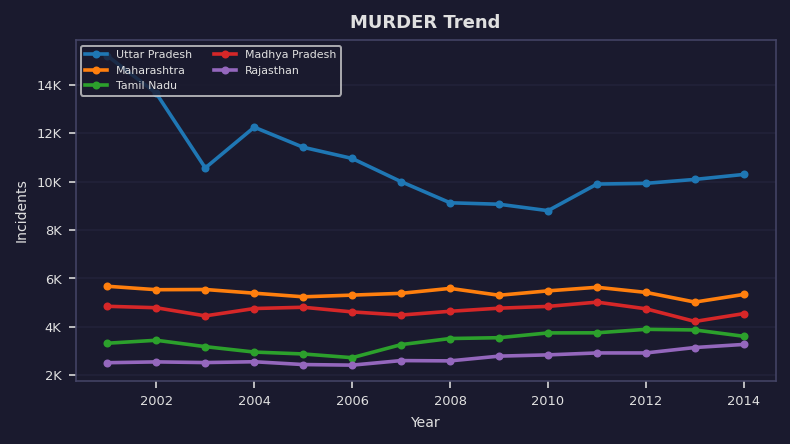
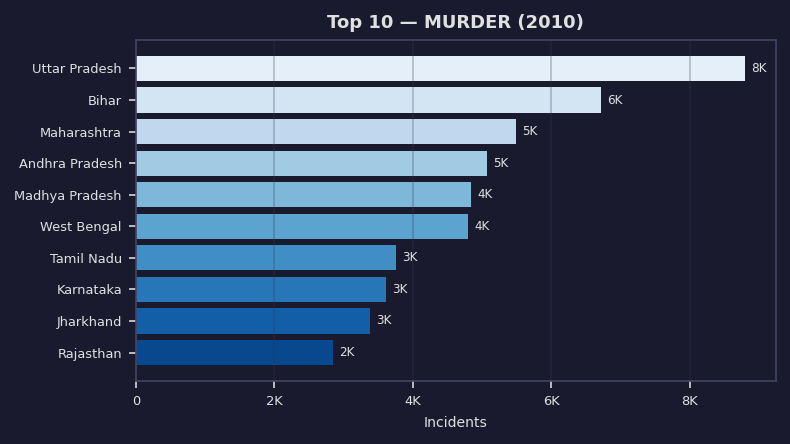
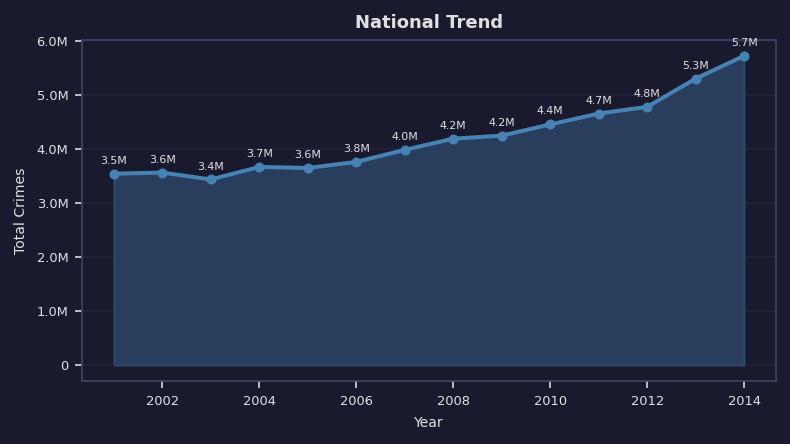
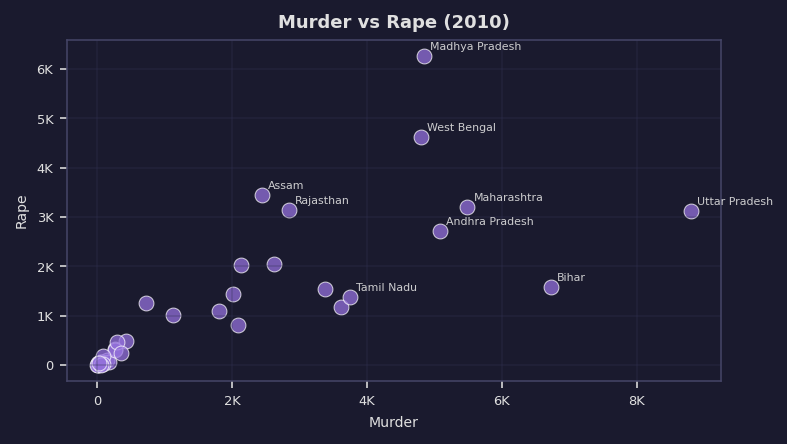
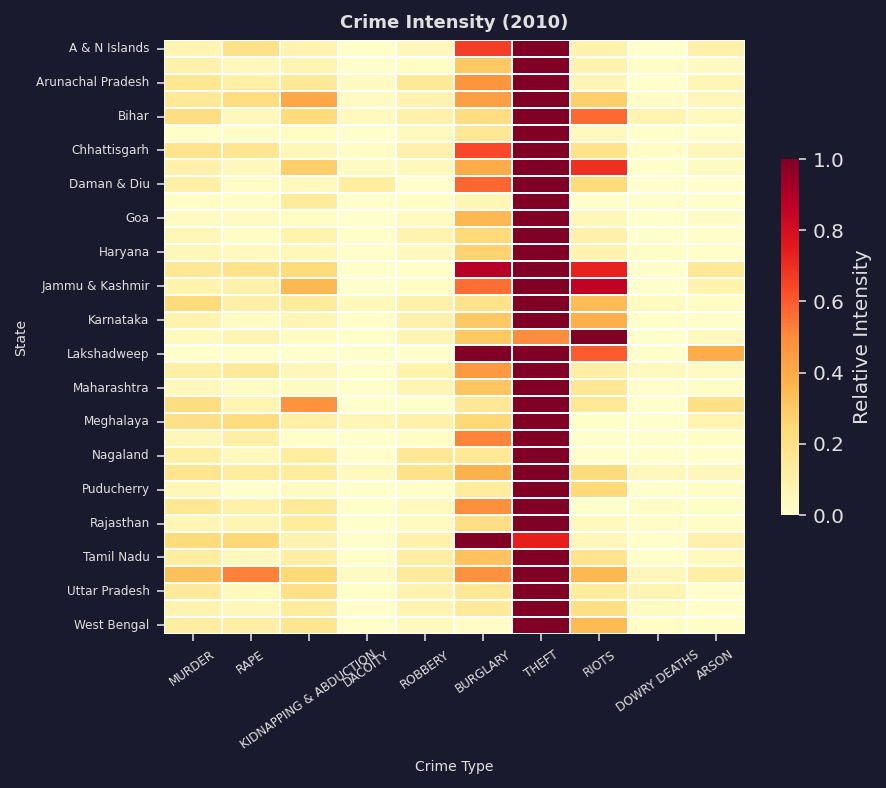
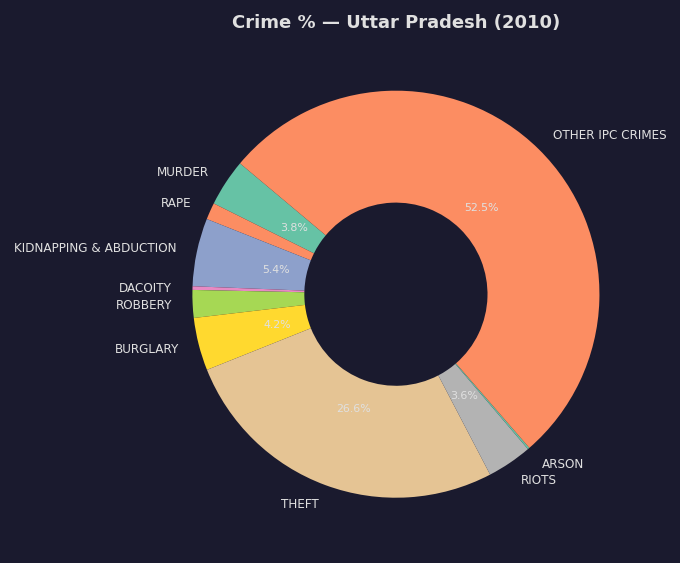

In [14]:
class CrimeDashboard(param.Parameterized):
    year       = param.ObjectSelector(default=2010, objects=ALL_YEARS)
    crime_line = param.ObjectSelector(
        default='MURDER',
        objects=['MURDER','RAPE','THEFT','RIOTS','DOWRY DEATHS','KIDNAPPING & ABDUCTION'])
    states     = param.ListSelector(
        default=['Uttar Pradesh','Maharashtra','Tamil Nadu','Madhya Pradesh','Rajasthan'],
        objects=ALL_STATES)
    crime_bar  = param.ObjectSelector(
        default='MURDER',
        objects=['MURDER','RAPE','DACOITY','ROBBERY','BURGLARY','ARSON'])
    topn       = param.ObjectSelector(default=10, objects=[5, 8, 10, 15])
    state_pie  = param.ObjectSelector(default='Uttar Pradesh', objects=ALL_STATES)

    @param.depends('year')
    def kpi_view(self):
        return make_kpi_cards(self.year)

    @param.depends('crime_line', 'states')
    def line_view(self):
        return make_line(self.crime_line, self.states)

    @param.depends('year', 'crime_bar', 'topn')
    def bar_view(self):
        return make_bar(self.year, self.crime_bar, self.topn)

    @param.depends('year')
    def scatter_view(self):
        return make_scatter(self.year)

    @param.depends('year')
    def heatmap_view(self):
        return make_heatmap(self.year)

    @param.depends('year', 'state_pie')
    def pie_view(self):
        return make_pie(self.year, self.state_pie)


dash = CrimeDashboard()

# ── Widgets wired directly to param ──────────────────────────────────────────
year_w       = pn.widgets.Select.from_param(dash.param.year,       name='Year',            width=200)
crime_line_w = pn.widgets.Select.from_param(dash.param.crime_line, name='Crime (Line)',     width=200)
states_w     = pn.widgets.MultiSelect.from_param(dash.param.states, name='States (Line)',  size=7, width=200)
crime_bar_w  = pn.widgets.Select.from_param(dash.param.crime_bar,  name='Crime (Bar)',      width=200)
topn_w       = pn.widgets.Select.from_param(dash.param.topn,       name='Top N States',     width=200)
pie_w        = pn.widgets.Select.from_param(dash.param.state_pie,  name='State (Donut)',    width=200)

sidebar = [
    pn.pane.Markdown('# 🚔 IPC Crime\nIndia 2001–2014'),
    pn.pane.Markdown('_Change any filter — all charts update instantly._'),
    pn.layout.Divider(),
    pn.pane.Markdown('### 📅 Year'),
    year_w,
    pn.layout.Divider(),
    pn.pane.Markdown('### 📈 Crime (Line)'),
    crime_line_w,
    pn.pane.Markdown('### 🗺️ States'),
    states_w,
    pn.layout.Divider(),
    pn.pane.Markdown('### 📊 Crime (Bar)'),
    crime_bar_w,
    pn.pane.Markdown('### 🔢 Top N'),
    topn_w,
    pn.layout.Divider(),
    pn.pane.Markdown('### 🍩 State (Donut)'),
    pie_w,
]

main = [
    pn.pane.Markdown('## 📊 Key Metrics'),
    pn.panel(dash.kpi_view),
    pn.Spacer(height=10),
    pn.Row(
        pn.Column(pn.pane.Markdown('#### Trend'),        pn.panel(dash.line_view),    sizing_mode='stretch_width'),
        pn.Column(pn.pane.Markdown('#### Top States'),   pn.panel(dash.bar_view),     sizing_mode='stretch_width'),
        sizing_mode='stretch_width'
    ),
    pn.Spacer(height=6),
    pn.Row(
        pn.Column(pn.pane.Markdown('#### National Trend'), area_chart_pane,                    sizing_mode='stretch_width'),
        pn.Column(pn.pane.Markdown('#### Murder vs Rape'), pn.panel(dash.scatter_view), sizing_mode='stretch_width'),
        sizing_mode='stretch_width'
    ),
    pn.Spacer(height=6),
    pn.Row(
        pn.Column(pn.pane.Markdown('#### Intensity'),    pn.panel(dash.heatmap_view), sizing_mode='stretch_width'),
        pn.Column(pn.pane.Markdown('#### Crime %'),      pn.panel(dash.pie_view),     sizing_mode='stretch_width'),
        sizing_mode='stretch_width'
    ),
]

template = pn.template.FastListTemplate(
    title='🚔 India IPC Crime Dashboard (2001–2014)',
    sidebar=sidebar,
    main=main,
    accent_base_color='#c0392b',
    header_background='#1a0a0a',
    theme='dark',
    theme_toggle=False,
)

template.show()
template.servable()
